In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
df = pd.read_csv("heart.csv")

print("First 5 rows:")
display(df.head())

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Dataset shape: (297, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


In [8]:
# Rename condition to target so our code stays consistent
df = df.rename(columns={'condition': 'target'})

# Confirm the rename worked
print("Columns now:", list(df.columns))
print("Target values:", df['target'].unique())

Columns now: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Target values: [0 1]


In [9]:
# The target column should be 0 (no disease) or 1 (disease present)
print("Target variable values:")
print(df['target'].value_counts())

print(f"\nClass distribution:")
print(f"No heart disease (0): {(df['target'] == 0).sum()} patients ({(df['target'] == 0).mean()*100:.1f}%)")
print(f"Heart disease (1):    {(df['target'] == 1).sum()} patients ({(df['target'] == 1).mean()*100:.1f}%)")

Target variable values:
target
0    160
1    137
Name: count, dtype: int64

Class distribution:
No heart disease (0): 160 patients (53.9%)
Heart disease (1):    137 patients (46.1%)


C:\Users\munee\AppData\Local\Temp\ipykernel_19064\2396206801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#2E75B6', '#C00000'])


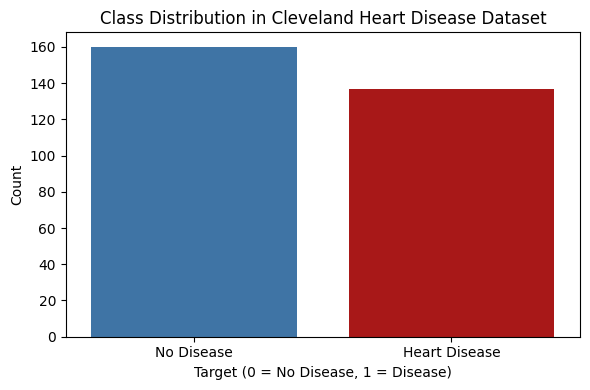

Chart saved


In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette=['#2E75B6', '#C00000'])
plt.title('Class Distribution in Cleveland Heart Disease Dataset')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Chart saved")

In [11]:
# X = the 13 input features (everything except target)
# y = the target column (what we want to predict)

X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")   # should be (297, 13)
print(f"Target shape:   {y.shape}")   # should be (297,)
print(f"\nFeature columns:\n{list(X.columns)}")

Features shape: (297, 13)
Target shape:   (297,)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [12]:
categorical_features = ['cp', 'restecg', 'slope', 'thal', 'ca']
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_features = ['sex', 'fbs', 'exang']

print("Categorical features:", categorical_features)
print("Continuous features: ", continuous_features)
print("Binary features:     ", binary_features)
print(f"\nTotal accounted for: {len(categorical_features) + len(continuous_features) + len(binary_features)} out of {X.shape[1]}")

Categorical features: ['cp', 'restecg', 'slope', 'thal', 'ca']
Continuous features:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary features:      ['sex', 'fbs', 'exang']

Total accounted for: 13 out of 13


In [13]:
from sklearn.preprocessing import StandardScaler

# Create a scaler — it learns the mean and standard deviation
# from the TRAINING data only
scaler = StandardScaler()

# Make copies so we keep the original unscaled version too
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Only scale the continuous features — not binary or categorical
X_train_scaled[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

# IMPORTANT: use transform (not fit_transform) on test data
# This applies the same scaling learned from training — never let
# the model learn anything from the test set
X_test_scaled[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

print("Scaling applied to continuous features only")
print(f"\nBefore scaling — age range in training: {X_train['age'].min()} to {X_train['age'].max()}")
print(f"After scaling  — age range in training: {X_train_scaled['age'].min():.2f} to {X_train_scaled['age'].max():.2f}")
print(f"\nBefore scaling — chol range in training: {X_train['chol'].min()} to {X_train['chol'].max()}")
print(f"After scaling  — chol range in training: {X_train_scaled['chol'].min():.2f} to {X_train_scaled['chol'].max():.2f}")

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation strategy defined")
print("Type: Stratified 5-Fold")
print("Purpose: main model evaluation on the full dataset")

## 6. Detailed Evaluation (Best Model)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

print("All model libraries imported successfully")

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    # Generate predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate all 5 metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    # Print results clearly
    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")

    return {
        'Model':     model_name,
        'Accuracy':  round(acc, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4),
        'F1-Score':  round(f1, 4),
        'AUC-ROC':   round(auc, 4)
    }

print("evaluate_model function ready")

## 7. Feature Importance (Tree-based models)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),
    
    "SVM": SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    )
}

print("4 models defined successfully:")
for name in models.keys():
    print("-", name)

In [ ]:
results = []

for name, model in models.items():
    
    # Choose which version of X to use
    if name in ["Logistic Regression", "SVM"]:
        X_used = X.copy()
        X_used[continuous_features] = StandardScaler().fit_transform(X[continuous_features])
    else:
        X_used = X.copy()
    
    scores = cross_validate(
        model,
        X_used,
        y,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        },
        n_jobs=-1
    )
    
    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'AUC-ROC': scores['test_roc_auc'].mean()
    })

print("Cross-validation complete.")